# 🚀 Advanced Seaborn

## Welcome!

You've already learned how to create beautiful visualizations and customize them using Seaborn.

Now it's time to explore Seaborn's **advanced statistical visualization capabilities**.

Unlike basic charts, these visualizations help uncover hidden relationships, trends, distributions, and statistical patterns within data, making them an essential part of Exploratory Data Analysis (EDA) and Machine Learning workflows.

Throughout this notebook, you'll learn how to create advanced statistical plots commonly used by data scientists and analysts to gain deeper insights from data.

These techniques are widely used in:

- 📊 Exploratory Data Analysis (EDA)
- 🤖 Machine Learning
- 💼 Business Analytics
- 🔬 Scientific Research
- 📈 Data Science

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- 📈 Visualize relationships between variables using advanced regression plots.
- 📉 Analyze model performance through residual visualizations.
- 📊 Explore distributions using cumulative and statistical plots.
- 🔍 Identify patterns, clusters, and hidden relationships within data.
- 🪟 Create advanced grid-based and statistical visualizations with Seaborn.
- 🎨 Customize advanced visualizations for clear and effective communication.
- 📄 Interpret statistical plots to support data-driven decision-making.
- 🚀 Perform deeper Exploratory Data Analysis (EDA) using Seaborn's advanced visualization tools.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
tips = sns.load_dataset("tips")

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# 📈 Regression Plot (`regplot`)

A **Regression Plot (`regplot`)** combines a **scatter plot** with a **linear regression line** to visualize the relationship between two numerical variables.

The scatter points represent the actual observations, while the regression line shows the overall trend in the data. This makes it easier to determine whether a positive, negative, or weak linear relationship exists between the variables.

### 📌 Why Use `regplot`?

- 📈 Visualize linear relationships between numerical variables.
- 🔍 Identify trends and correlations in the data.
- 📊 Understand how changes in one variable affect another.
- 📉 Detect potential outliers that deviate from the trend.
- 🤖 Perform exploratory analysis before building regression models.

### 🌍 Real-World Example

A business analyst may use `regplot` to examine the relationship between **advertising expenditure** and **sales revenue**. If the regression line shows a positive trend, it suggests that increasing advertising spending is associated with higher sales.

Similarly, in the **Tips** dataset, `regplot` can help analyze whether customers with **higher total bills** tend to leave **higher tips**.

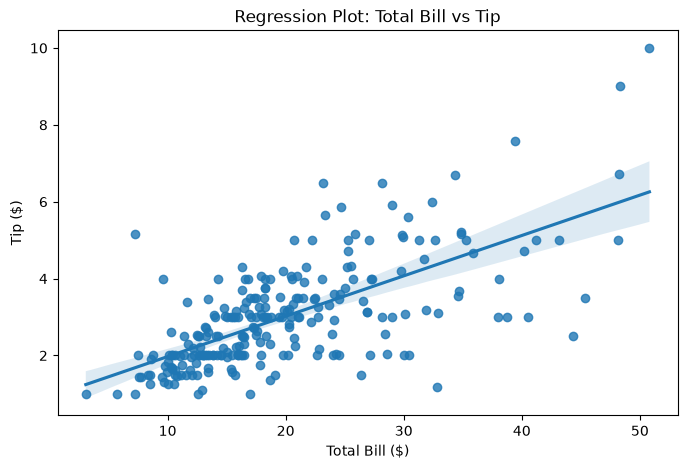

In [4]:
# Create a figure
plt.figure(figsize=(8, 5))

# Create a regression plot
sns.regplot(
    data=tips,
    x="total_bill",
    y="tip"
)

# Add title
plt.title("Regression Plot: Total Bill vs Tip")

# Add axis labels
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")

# Display the plot
plt.show()

### 📌 Observation

- A **positive linear relationship** exists between **Total Bill** and **Tip**, indicating that customers generally leave higher tips as the total bill increases.
- Most observations are concentrated between **$10–$25** for the total bill and **$1.5–$4** for the tip, suggesting these are the most common transaction values.
- The regression line has an **upward slope**, confirming an overall positive trend between the two variables.
- The confidence interval widens at higher bill amounts, indicating **greater uncertainty** due to fewer observations in that range.
- A few observations with **high bills and high tips** are visible, but they do not substantially change the overall positive trend.
- Although the relationship is positive, the data points are **not perfectly aligned** with the regression line, indicating that factors other than the total bill also influence the tip amount.

# 📊 Linear Model Plot (`lmplot`)

A **Linear Model Plot (`lmplot`)** extends the functionality of `regplot()` by allowing regression analysis across different categories.

In addition to displaying a **scatter plot** and a **linear regression line**, `lmplot()` can create **separate regression lines** for different groups using categorical variables. This makes it easy to compare trends across multiple categories within the same dataset.

### 📌 Why Use `lmplot()`?

- 📈 Visualize linear relationships between numerical variables.
- 🏷️ Compare regression trends across different categories.
- 🔍 Identify differences in relationships between groups.
- 📊 Explore interactions between numerical and categorical variables.
- 🤖 Perform grouped exploratory analysis before building machine learning models.

### 🌍 Real-World Example

A retail company may use `lmplot()` to compare the relationship between **advertising expenditure** and **sales revenue** across different **marketing channels**.

Similarly, in the **Tips** dataset, `lmplot()` can compare the relationship between **Total Bill** and **Tip** for different customer groups, such as **Lunch vs Dinner** or **Smoker vs Non-Smoker**.

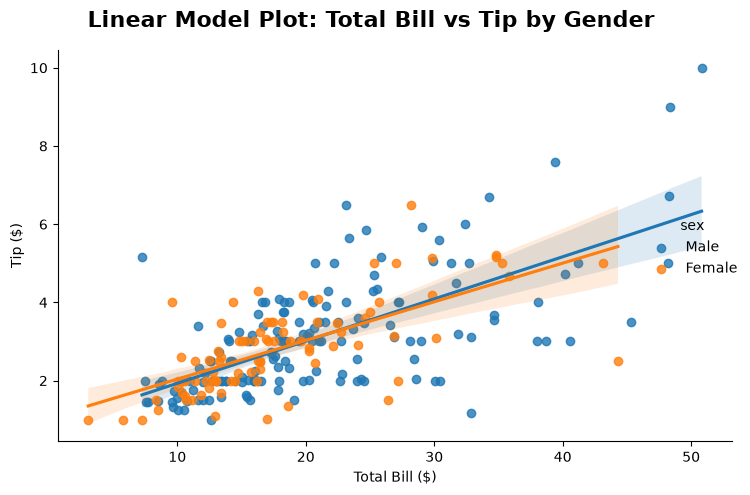

In [5]:
# Create a linear model plot
g = sns.lmplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",
    height=5,
    aspect=1.3
)

# Add title
g.fig.suptitle(
    "Linear Model Plot: Total Bill vs Tip by Gender",
    fontsize=16,
    fontweight="bold"
)

# Add axis labels
g.set_axis_labels(
    "Total Bill ($)",
    "Tip ($)"
)

# Adjust layout
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.90)

# Display the plot
plt.show()

### 📌 Observation

- Both **Male** and **Female** customers exhibit a **positive linear relationship** between **Total Bill** and **Tip**, indicating that tips generally increase as the total bill increases.
- The regression lines for both groups have **similar upward trends**, suggesting that the relationship between bill amount and tip is consistent across genders.
- Male customers show a **wider spread of observations**, particularly for higher bill amounts, indicating greater variability in both total bills and tips.
- Female customers are more concentrated in the **lower to moderate bill range**, with fewer observations at very high bill values.
- The confidence intervals for both regression lines overlap considerably, suggesting **no strong visual difference** in the overall tipping trend between male and female customers.
- A few customers from both groups have relatively **high bills and high tips**, but these observations do not substantially alter the overall positive trend.

# 📉 Residual Plot (`residplot`)

A **Residual Plot (`residplot`)** is used to evaluate how well a **linear regression model** fits the data.

Residuals represent the difference between the **observed (actual)** values and the **predicted** values generated by the regression model.

### 📌 Residual Formula

**Residual = Observed Value − Predicted Value**

A well-fitted regression model produces residuals that are **randomly scattered around zero**, without any clear pattern. Random residuals indicate that the linear model is appropriate for the data.

### 📌 Why Use `residplot()`?

- 📉 Evaluate the performance of a regression model.
- 🔍 Check whether a linear model is appropriate for the data.
- 📊 Identify non-linear patterns that the model fails to capture.
- 🚨 Detect potential outliers and unusual observations.
- 🤖 Validate assumptions before building predictive machine learning models.

### 🌍 Real-World Example

A business analyst may build a regression model to predict **sales** based on **advertising expenditure**. A residual plot helps verify whether the model accurately captures the relationship or whether important patterns remain unexplained.

Similarly, in the **Tips** dataset, a residual plot can be used to evaluate how well **Total Bill** predicts the **Tip** left by customers.

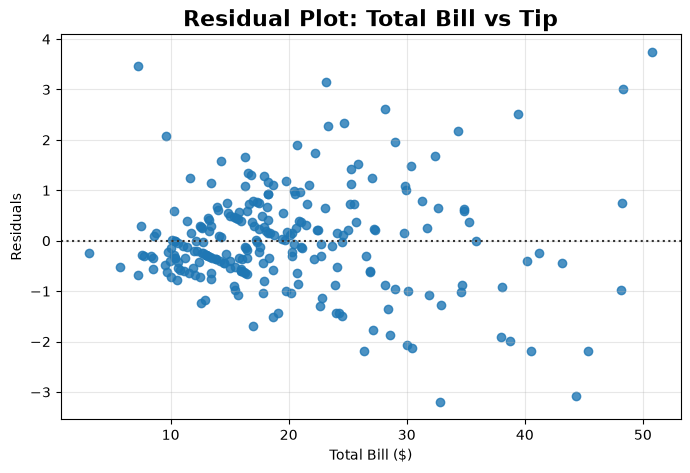

In [6]:
# Create a figure
plt.figure(figsize=(8, 5))

# Create a residual plot
sns.residplot(
    data=tips,
    x="total_bill",
    y="tip"
)

# Add title
plt.title(
    "Residual Plot: Total Bill vs Tip",
    fontsize=16,
    fontweight="bold"
)

# Add axis labels
plt.xlabel("Total Bill ($)")
plt.ylabel("Residuals")

# Add a subtle grid
plt.grid(alpha=0.3)

# Display the plot
plt.show()

### 📌 Observation

- The residuals are randomly scattered around the zero line, indicating that the linear regression model fits the data reasonably well.
- Most residuals are close to zero, suggesting that the model predicts tip amounts accurately for most observations.
- The spread of residuals increases slightly for higher total bill values, indicating greater variability in prediction errors for larger bills.
- Overall, no strong pattern is visible in the residuals, supporting the assumption of a linear relationship between **Total Bill** and **Tip**.

# 📈 Empirical Cumulative Distribution Function (`ecdfplot`)

An **Empirical Cumulative Distribution Function (ECDF)** visualizes the cumulative proportion of observations that are **less than or equal to a given value**.

Unlike a histogram or KDE plot, an ECDF displays the **entire distribution without using bins**, making it a precise and informative way to understand how data accumulates across its range.

### 📌 Why Use `ecdfplot()`?

- 📊 Understand the cumulative distribution of numerical data.
- 📈 Determine the proportion of observations below a specific value.
- 🔍 Compare distributions across different categories.
- 📉 Identify percentiles, medians, and extreme values.
- 🤖 Explore data distributions during Exploratory Data Analysis (EDA).

### 🌍 Real-World Example

A retail company can use an ECDF plot to determine **what percentage of customers spend less than a certain amount** during a purchase.

Similarly, in the **Tips** dataset, an ECDF plot can show **the cumulative percentage of customers whose total bill is less than or equal to a given value**, helping analyze customer spending behavior.

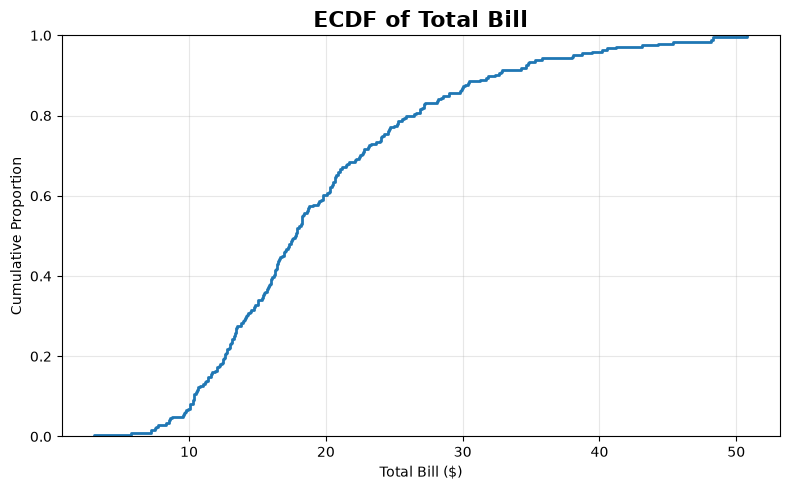

In [7]:
# Create a figure
plt.figure(figsize=(8, 5))

# Plot the Empirical Cumulative Distribution Function (ECDF)
sns.ecdfplot(
    data=tips,
    x="total_bill",
    linewidth=2
)

# Add title
plt.title(
    "ECDF of Total Bill",
    fontsize=16,
    fontweight="bold"
)

# Add axis labels
plt.xlabel("Total Bill ($)")
plt.ylabel("Cumulative Proportion")

# Add a subtle grid
plt.grid(alpha=0.3)

# Optimize layout
plt.tight_layout()

# Display the plot
plt.show()

### 📌 Observation

- The ECDF curve increases steadily, indicating that **Total Bill** values are distributed across a wide range without abrupt jumps.
- Approximately **60%** of the observations have a **Total Bill of around \$20 or less**, showing that lower to moderate bills are more common.
- The curve gradually flattens for higher bill amounts, indicating that **large bills occur less frequently** in the dataset.
- Overall, the ECDF provides a clear view of the cumulative distribution, making it easy to estimate the proportion of observations below any given bill amount.

# 📍 Rug Plot (`rugplot`)

A **Rug Plot (`rugplot`)** displays a small tick mark for **every individual observation** along an axis, allowing you to see the exact location of each data point.

Unlike histograms or KDE plots, a Rug Plot does not summarize the data. Instead, it preserves every observation, making it useful for understanding the true distribution of values.

Rug plots are commonly combined with **histograms**, **KDE plots**, or **ECDF plots** to provide additional insight into the underlying data distribution.

### 📌 Why Use `rugplot()`?

- 📍 Display the exact position of every observation.
- 📊 Reveal how data points are distributed across the range.
- 🔍 Identify clusters, gaps, and potential outliers.
- 📈 Complement histograms and KDE plots with raw observations.
- 🤖 Improve exploratory data analysis by visualizing individual data points.

### 🌍 Real-World Example

A business analyst may use a Rug Plot alongside a histogram to examine **customer purchase amounts**. The histogram shows the overall distribution, while the Rug Plot reveals the exact spending value of each customer.

Similarly, in the **Tips** dataset, a Rug Plot helps visualize the exact **Total Bill** values for every customer, making it easier to identify spending patterns and unusual observations.

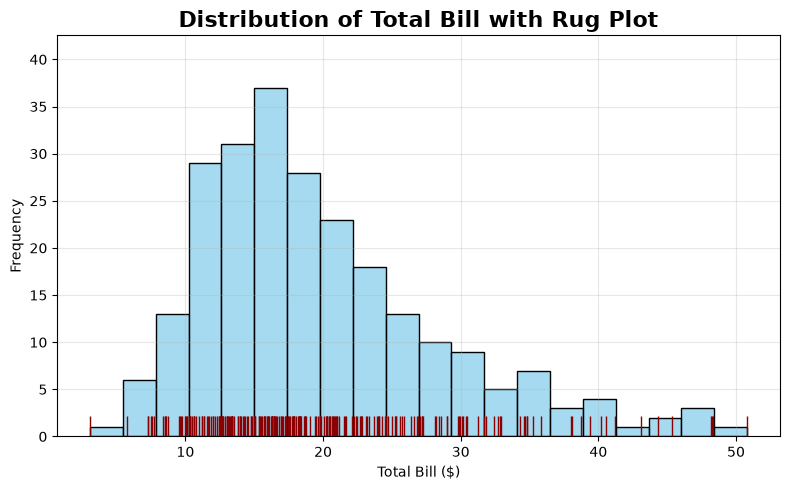

In [8]:
# Create a figure
plt.figure(figsize=(8, 5))

# Plot a histogram
sns.histplot(
    data=tips,
    x="total_bill",
    bins=20,
    color="skyblue",
    edgecolor="black"
)

# Add a rug plot
sns.rugplot(
    data=tips,
    x="total_bill",
    color="darkred",
    height=0.05
)

# Add title
plt.title(
    "Distribution of Total Bill with Rug Plot",
    fontsize=16,
    fontweight="bold"
)

# Add axis labels
plt.xlabel("Total Bill ($)")
plt.ylabel("Frequency")

# Add a subtle grid
plt.grid(alpha=0.3)

# Optimize layout
plt.tight_layout()

# Display the plot
plt.show()

### 📌 Observation

- The histogram shows a **right-skewed distribution**, indicating that most customers have lower to moderate total bills, while very high bills are less common.
- Most observations are concentrated between **$10 and $25**, representing the most frequent total bill range.
- The rug plot displays the exact location of each observation, revealing a higher density of data points in the lower bill range and fewer observations at higher bill values.
- Only a small number of observations exceed **$40**, suggesting that large restaurant bills are relatively rare in this dataset.

# 🧩 Cluster Map (`clustermap`)

A **Cluster Map (`clustermap`)** combines a **heatmap** with **hierarchical clustering** to visualize patterns and relationships within a dataset.

Unlike a standard heatmap, a Cluster Map automatically groups similar **rows** and **columns** based on their values. This makes it easier to identify clusters, hidden structures, and similarities in complex datasets.

### 📌 Why Use `clustermap()`?

- 🔍 Discover natural clusters in the data.
- 📊 Visualize similarities between observations and features.
- 📈 Identify hidden patterns and relationships.
- 🧬 Analyze high-dimensional datasets effectively.
- 🤖 Support exploratory data analysis before applying machine learning algorithms.

### 🌍 Real-World Example

Researchers use Cluster Maps to analyze **gene expression data**, where genes with similar behavior are grouped together.

In business analytics, a Cluster Map can be used to **segment customers** based on purchasing behavior or identify groups of highly correlated features before building machine learning models.

### 📌 Common Applications

- 🧬 Gene expression analysis
- 👥 Customer segmentation
- 📊 Feature clustering
- 🔗 Correlation analysis
- 🤖 Machine Learning feature exploration

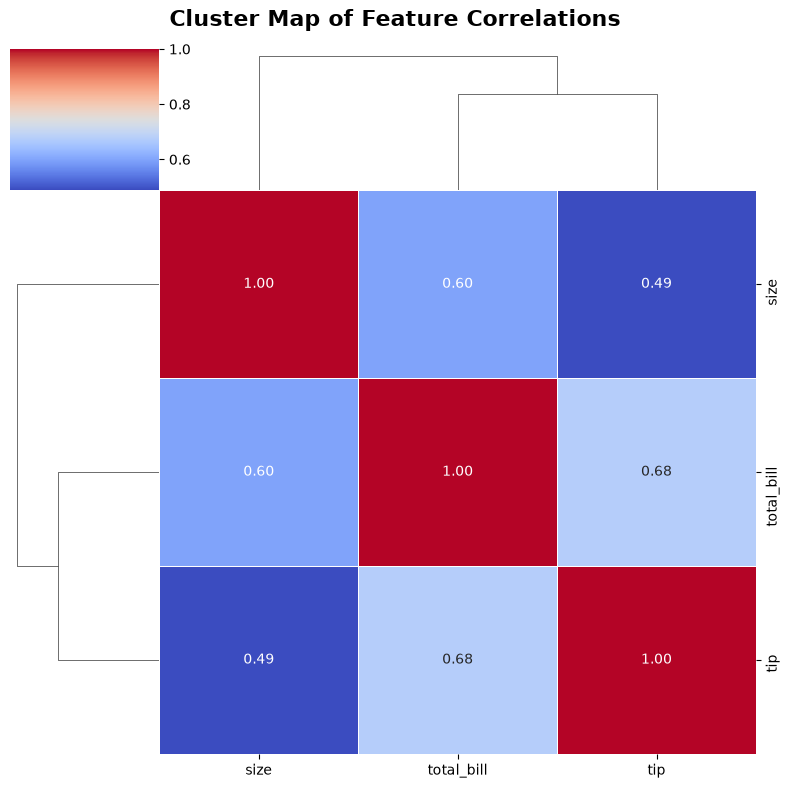

In [9]:
# Compute the correlation matrix
correlation = tips.corr(numeric_only=True)

# Create a cluster map
g = sns.clustermap(
    correlation,
    annot=True,
    cmap="coolwarm",
    figsize=(8, 8),
    linewidths=0.5,
    fmt=".2f"
)

# Add title
g.fig.suptitle(
    "Cluster Map of Feature Correlations",
    fontsize=16,
    fontweight="bold"
)

# Adjust layout
g.fig.subplots_adjust(top=0.93)

# Display the plot
plt.show()

### 📌 Observation

- The Cluster Map groups **`total_bill`** and **`tip`** together, indicating that these two variables have the strongest positive relationship (**correlation ≈ 0.68**).
- **`size`** is also positively correlated with both variables, but its relationship with **`tip`** (**≈ 0.49**) is weaker than its relationship with **`total_bill`** (**≈ 0.60**).
- The dendrogram shows that **`total_bill`** and **`tip`** are more similar to each other than to **`size`**, suggesting they form a natural cluster.
- Overall, the Cluster Map effectively highlights the similarity between features, making it easier to identify related variables for exploratory data analysis.

# 🔥 Advanced Heatmap

An **Advanced Heatmap** extends a basic heatmap by incorporating features such as **annotations**, **custom color palettes**, **line widths**, and **value formatting** to improve readability and interpretation.

It transforms numerical data into color-coded patterns, making it easier to identify relationships, trends, and high or low values at a glance.

### 📌 Why Use an Advanced Heatmap?

- 🌡️ Visualize relationships between numerical variables.
- 📊 Highlight strong and weak correlations.
- 🔍 Detect hidden patterns and anomalies.
- 📈 Improve readability with annotations and custom styling.
- 🤖 Support exploratory data analysis and machine learning workflows.

### 🌍 Real-World Example

A data analyst can use an Advanced Heatmap to identify **highly correlated features** before training a machine learning model, helping reduce multicollinearity.

Similarly, businesses use heatmaps to analyze **sales performance**, **customer behavior**, or **website activity**, where colors quickly highlight important trends.

### 📌 Common Applications

- 📊 Correlation matrices
- ❓ Missing value visualization
- 📋 Pivot tables
- 🤖 Machine learning feature analysis
- 📈 Model evaluation metrics (e.g., confusion matrices)

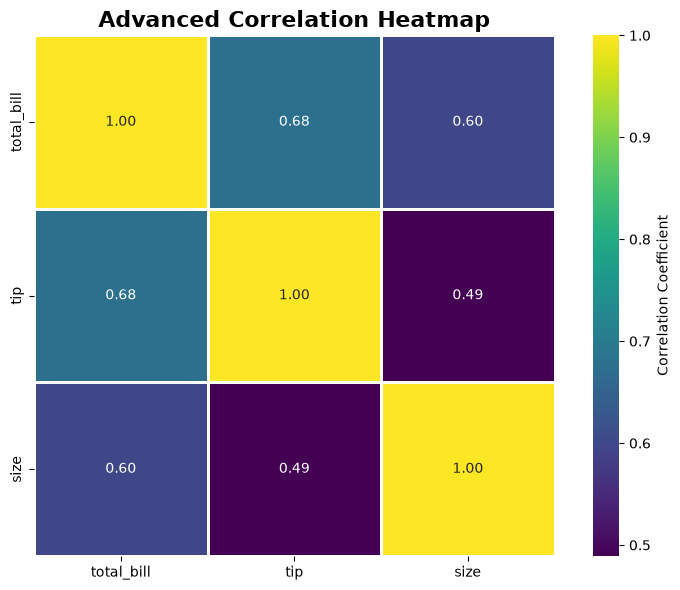

In [10]:
# Compute the correlation matrix
correlation = tips.corr(numeric_only=True)

# Create a figure
plt.figure(figsize=(8, 6))

# Create an advanced heatmap
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.8,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Correlation Coefficient"}
)

# Add title
plt.title(
    "Advanced Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

# Optimize layout
plt.tight_layout()

# Display the plot
plt.show()

### 📌 Observation

- The heatmap shows **positive correlations** among all numerical variables, indicating that they tend to increase together.
- **`total_bill`** and **`tip`** have the strongest positive correlation (**0.68**), suggesting that higher bills are generally associated with higher tips.
- **`size`** is moderately correlated with **`total_bill`** (**0.60**) and more weakly correlated with **`tip`** (**0.49**), indicating that larger groups tend to have higher bills but only a moderate increase in tips.
- Overall, the heatmap provides a quick and effective overview of the relationships between numerical features, helping identify variables that are more closely associated.

# 🔗 Advanced Pair Plot

An **Advanced Pair Plot** extends the basic `pairplot()` by incorporating **categorical grouping**, **custom diagonal plots**, and **styling options** to provide a more comprehensive view of relationships between numerical variables.

It allows you to simultaneously examine **distributions**, **correlations**, and **group differences**, making it one of the most powerful tools for Exploratory Data Analysis (EDA).

### 📌 Why Use an Advanced Pair Plot?

- 📊 Explore pairwise relationships between multiple numerical features.
- 🎨 Compare different categories using the `hue` parameter.
- 📈 Visualize feature distributions on the diagonal.
- 🔍 Detect trends, clusters, and potential outliers.
- 🤖 Perform comprehensive exploratory data analysis before building machine learning models.

### 🌍 Real-World Example

A data scientist can use an Advanced Pair Plot to analyze customer data and determine how features such as **age**, **income**, and **annual spending** relate to one another across different customer segments.

Similarly, in the **Tips** dataset, an Advanced Pair Plot helps compare relationships between **Total Bill**, **Tip**, and **Party Size**, while also distinguishing observations based on variables such as **Time**, **Day**, or **Smoker** status.

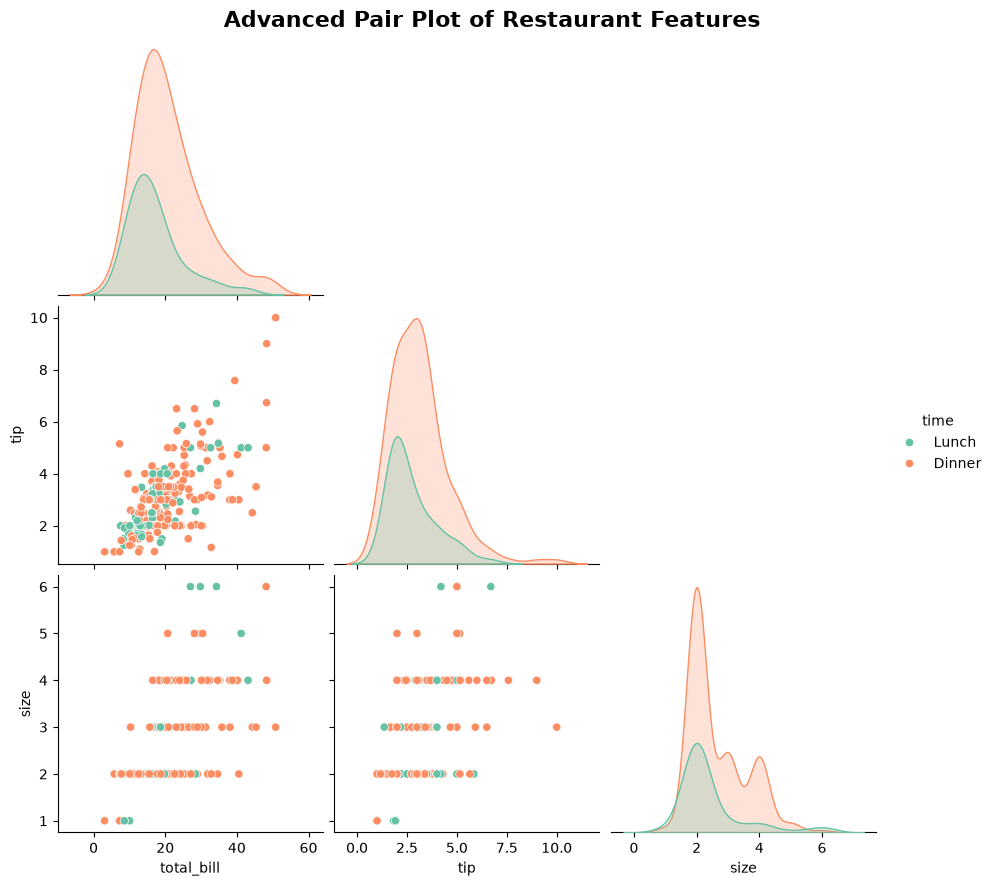

In [11]:
# Create an advanced pair plot
g = sns.pairplot(
    tips,
    vars=["total_bill", "tip", "size"],
    hue="time",
    diag_kind="kde",
    palette="Set2",
    corner=True,
    height=3
)

# Add a title
g.fig.suptitle(
    "Advanced Pair Plot of Restaurant Features",
    fontsize=16,
    fontweight="bold"
)

# Adjust layout to prevent title overlap
g.fig.subplots_adjust(top=0.95)

# Display the plot
plt.show()

### 📌 Observation

- The pair plot reveals a **positive relationship** between **Total Bill** and **Tip**, indicating that higher bills are generally associated with higher tips.
- Most observations are concentrated in the **lower to moderate** ranges of **Total Bill**, **Tip**, and **Party Size**, while higher values occur less frequently.
- The KDE plots on the diagonal show **right-skewed distributions**, suggesting that most customers have smaller bills, lower tips, and smaller party sizes.
- The distributions for **Lunch** and **Dinner** overlap considerably, although **Dinner** has a wider spread and includes more high-value observations than **Lunch**.

# 📊 Joint Plot Variants

`jointplot()` supports multiple visualization styles, allowing you to analyze the relationship between two numerical variables from different perspectives.

Each variant combines a **central joint plot** with **marginal distributions**, making it a powerful tool for exploratory data analysis (EDA).

### 📌 Common `kind` Options

| Kind | Description | Best Used For |
|------|-------------|---------------|
| `scatter` | Displays individual data points | Exploring relationships and detecting outliers |
| `kde` | Shows smooth density contours | Understanding data density and concentration |
| `hex` | Groups points into hexagonal bins | Large datasets with overlapping observations |
| `hist` | Uses 2D histograms | Visualizing frequency distributions |
| `reg` | Adds a regression line | Examining linear relationships and trends |

### 📌 Why Use Different Variants?

- 📊 Explore relationships between two numerical variables.
- 📈 Analyze marginal distributions alongside the joint relationship.
- 🔍 Detect clusters, outliers, and dense regions.
- 📉 Examine linear trends using regression.
- 🤖 Support exploratory data analysis before machine learning.

### 🌍 Real-World Example

A business analyst may use different Joint Plot variants to study the relationship between **advertising expenditure** and **sales**. While a scatter plot reveals individual observations, a regression plot highlights the overall trend, and a KDE plot identifies regions where observations are most concentrated.

Similarly, in the **Tips** dataset, different Joint Plot variants help analyze how **Total Bill** and **Tip** are related from multiple analytical perspectives.

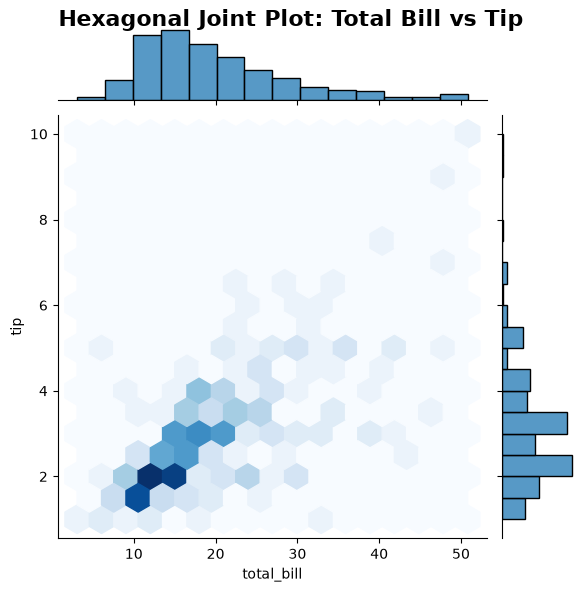

In [12]:
# Create a hexagonal joint plot
g = sns.jointplot(
    data=tips,
    x="total_bill",
    y="tip",
    kind="hex",
    height=6,
    cmap="Blues"
)

# Add a title
g.fig.suptitle(
    "Hexagonal Joint Plot: Total Bill vs Tip",
    fontsize=16,
    fontweight="bold"
)

# Adjust layout to prevent title overlap
g.fig.subplots_adjust(top=0.95)

# Display the plot
plt.show()

### 📌 Observation

- The darkest hexagonal bins are concentrated around **Total Bill ($10–$20)** and **Tip ($1.5–$3.5)**, indicating that this is the most common combination in the dataset.
- The hexagonal pattern reveals a **positive relationship** between **Total Bill** and **Tip**, with higher bills generally associated with higher tips.
- The marginal histograms show that most customers have **lower to moderate** bill amounts and tip values, while higher values occur less frequently.
- The density decreases as both the total bill and tip increase, indicating that **large bills and high tips are relatively uncommon** in the dataset.

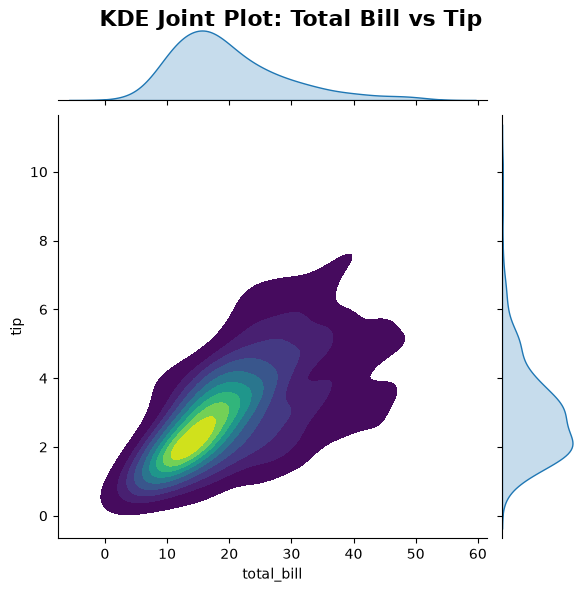

In [13]:
# Create a KDE joint plot
g = sns.jointplot(
    data=tips,
    x="total_bill",
    y="tip",
    kind="kde",
    fill=True,
    cmap="viridis",
    height=6
)

# Add a title
g.fig.suptitle(
    "KDE Joint Plot: Total Bill vs Tip",
    fontsize=16,
    fontweight="bold"
)

# Adjust layout to prevent title overlap
g.fig.subplots_adjust(top=0.95)

# Display the plot
plt.show()

### 📌 Observation

- The highest density region is concentrated around **Total Bill ($10–$20)** and **Tip ($2–$3)**, indicating that these are the most common values in the dataset.
- The density contours show a **positive relationship** between **Total Bill** and **Tip**, with tips generally increasing as the total bill increases.
- The marginal KDE plots indicate that both **Total Bill** and **Tip** are **right-skewed**, meaning lower to moderate values are more common than higher values.
- The density gradually decreases for larger bill and tip amounts, suggesting that **high bills and high tips occur less frequently** in the dataset.

# 📉 Comparing Distributions

Comparing distributions helps us understand **how numerical data differs across categories**. It allows us to examine differences in **central tendency**, **variability**, **shape**, and the presence of **outliers**.

Distribution comparison is a fundamental step in **Exploratory Data Analysis (EDA)** because it reveals patterns that summary statistics alone may not capture.

### 📌 Why Compare Distributions?

- 📊 Compare the spread of values across different groups.
- 📈 Identify differences in the median and overall distribution.
- 📉 Detect skewness and potential outliers.
- 🔍 Understand variability between categories.
- 🤖 Explore group-wise patterns before statistical analysis or machine learning.

### 🌍 Real-World Example

A restaurant owner may compare the distribution of **customer bills** between different groups (such as lunch vs. dinner or male vs. female customers) to understand spending behavior.

Similarly, in the **Tips** dataset, we'll compare the distribution of **Total Bill** by **Gender** to explore whether the spending patterns differ between male and female customers.

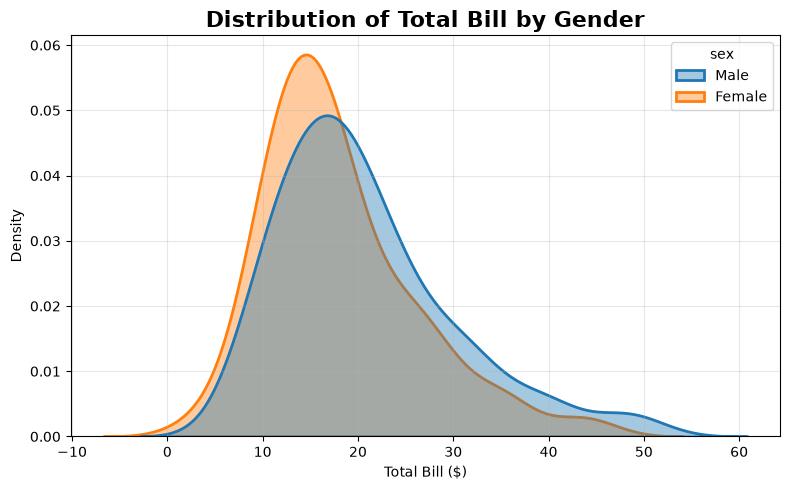

In [14]:
# Create a figure
plt.figure(figsize=(8, 5))

# Compare distributions using KDE plots
sns.kdeplot(
    data=tips,
    x="total_bill",
    hue="sex",
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2
)

# Add title
plt.title(
    "Distribution of Total Bill by Gender",
    fontsize=16,
    fontweight="bold"
)

# Add axis labels
plt.xlabel("Total Bill ($)")
plt.ylabel("Density")

# Add a subtle grid
plt.grid(alpha=0.3)

# Optimize layout
plt.tight_layout()

# Display the plot
plt.show()

### 📌 Observation

- Both **Male** and **Female** customers exhibit **right-skewed distributions**, indicating that lower to moderate total bill amounts are more common than higher bills.
- The distributions overlap considerably, suggesting that both groups have **similar spending patterns** overall.
- The distribution for **Male** customers is slightly wider, indicating greater variability and a higher occurrence of large bill amounts.
- The highest density for both groups is concentrated around **$10–$20**, showing that this is the most common total bill range in the dataset.

# 📈 Categorical Statistical Analysis

Categorical statistical plots summarize **numerical data across different categories**, making it easier to compare group-wise statistics such as the **mean**, **median**, **confidence intervals**, and overall trends.

These visualizations are widely used during **Exploratory Data Analysis (EDA)** to understand how a numerical variable changes across categorical groups.

### 📌 Why Use Categorical Statistical Plots?

- 📊 Compare summary statistics across categories.
- 📈 Identify differences in average values.
- 📉 Detect trends and variations between groups.
- 🔍 Explore relationships between categorical and numerical variables.
- 🤖 Support data-driven decision-making before statistical modeling or machine learning.

### 🌍 Real-World Example

A restaurant manager may compare the **average tip amount** across different days of the week to determine when customers tend to leave higher tips.

Similarly, in the **Tips** dataset, we'll compare the **average tip amount for each day**, grouped by **Gender**, to explore differences in tipping behavior.

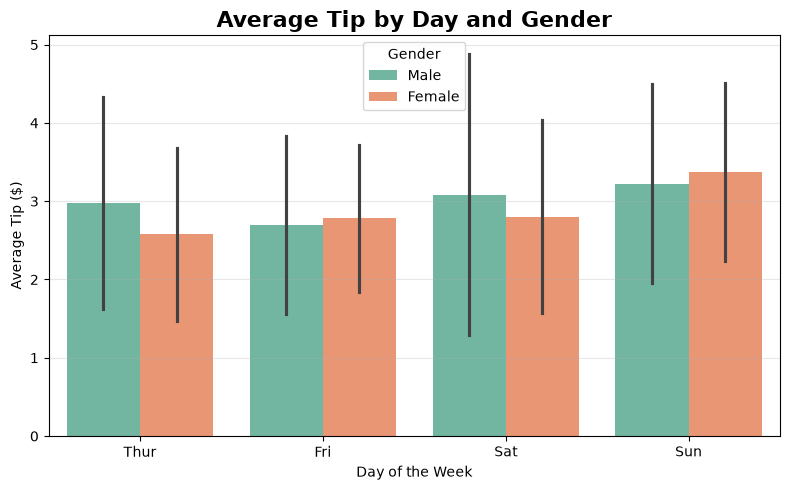

In [15]:
# Create a figure
plt.figure(figsize=(8, 5))

# Compare the average tip amount by day and gender
sns.barplot(
    data=tips,
    x="day",
    y="tip",
    hue="sex",
    errorbar="sd",
    palette="Set2"
)

# Add title
plt.title(
    "Average Tip by Day and Gender",
    fontsize=16,
    fontweight="bold"
)

# Add axis labels
plt.xlabel("Day of the Week")
plt.ylabel("Average Tip ($)")

# Add a subtle grid
plt.grid(axis="y", alpha=0.3)

# Customize legend
plt.legend(
    title="Gender",
    frameon=True
)

# Optimize layout
plt.tight_layout()

# Display the plot
plt.show()

### 📌 Observation

- The average tip varies slightly across different days of the week, with **Sunday** showing the highest average tip for both genders.
- Male and Female customers exhibit **similar tipping patterns**, with only small differences in average tip amounts across most days.
- The error bars indicate noticeable variability in tip amounts within each group, particularly on **Saturday**, suggesting a wider spread of tipping behavior.
- Overall, the average tip remains relatively consistent throughout the week, with no substantial differences between genders.

# 🌟 Professional Statistical EDA Example

Let's combine multiple **Seaborn** and **Matplotlib** features to create a polished statistical visualization suitable for **exploratory data analysis (EDA)**, **presentations**, and **professional reports**.

In this example, we'll apply several visualization techniques together, including:

- 🎨 Professional styling and color palettes
- 📊 Statistical aggregation
- 🏷️ Informative titles and axis labels
- 📈 Category-wise comparison
- 🔍 Clear legends and improved readability

### 🎯 Objective

The goal is to demonstrate how multiple customization techniques can be combined to create a visualization that is both **informative** and **presentation-ready**, following best practices commonly used by data analysts and machine learning practitioners.

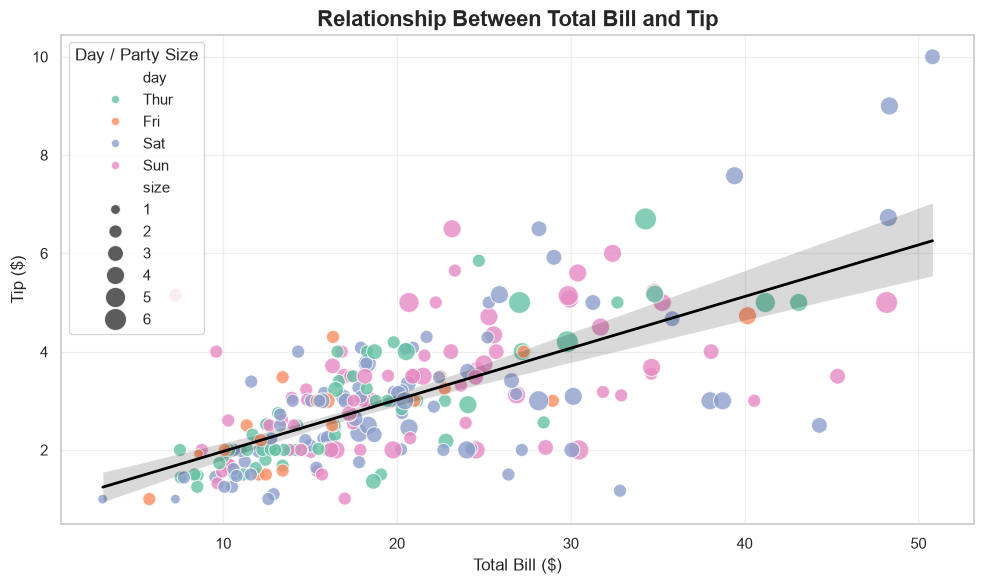

In [16]:
# Apply a professional theme
sns.set_theme(style="whitegrid")

# Create a figure
plt.figure(figsize=(10, 6))

# Create a scatter plot
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="day",
    size="size",
    palette="Set2",
    sizes=(50, 250),
    alpha=0.8
)

# Add a regression line
sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2}
)

# Add title
plt.title(
    "Relationship Between Total Bill and Tip",
    fontsize=16,
    fontweight="bold"
)

# Add axis labels
plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Tip ($)", fontsize=12)

# Customize legend
plt.legend(
    title="Day / Party Size",
    frameon=True,
    loc="upper left"
)

# Add a subtle grid
plt.grid(alpha=0.3)

# Optimize layout
plt.tight_layout()

# Display the plot
plt.show()

### 📌 Observation

- The scatter plot and regression line indicate a **positive relationship** between **Total Bill** and **Tip**, suggesting that customers generally leave higher tips as the bill amount increases.
- Larger marker sizes (representing bigger party sizes) are more common at higher bill amounts, indicating that larger groups tend to generate larger bills.
- Spending patterns are observed across all days of the week, with a similar overall trend despite differences in individual observations.
- Although the overall trend is positive, the spread of points increases for higher bill amounts, indicating greater variability in tip values for expensive bills.

# 💡 Best Practices

Follow these best practices to create clear, informative, and professional statistical visualizations with **Seaborn**:

- 📊 Understand your dataset before selecting a visualization.
- 🎯 Choose the plot that best answers your analytical question.
- 🎨 Use color palettes that improve readability and accessibility.
- 📈 Display statistical summaries (such as regression lines or confidence intervals) only when they add meaningful insight.
- 🏷️ Write clear titles, axis labels, and legends.
- 🧹 Keep visualizations simple and avoid unnecessary visual clutter.
- 🔍 Validate findings using multiple visualization techniques instead of relying on a single chart.
- 🤝 Combine Seaborn with Matplotlib for advanced customization and presentation-quality figures.
- 📚 Interpret visualizations alongside statistical analysis rather than drawing conclusions from charts alone.
- 🚀 Design visualizations that communicate insights effectively to both technical and non-technical audiences.

# ❌ Common Mistakes

Avoid these common mistakes when creating statistical visualizations with **Seaborn**:

- 📊 Choosing an inappropriate plot type for the data or analysis.
- 🚫 Ignoring missing values or outliers before visualization.
- 🎨 Using misleading or low-contrast color palettes.
- 📦 Overloading a single plot with too many variables (`hue`, `size`, and `style`) at the same time.
- 🏷️ Forgetting descriptive titles, axis labels, or legends.
- 📉 Misinterpreting correlation as causation.
- 📈 Drawing conclusions from visualizations without supporting statistical evidence.
- 🔍 Relying on a single visualization instead of validating findings with multiple plots.
- 📏 Ignoring sample size when interpreting distributions or statistical summaries.
- ⚖️ Overlooking scales and axis ranges, which can exaggerate or hide patterns.

# 📌 Key Takeaways

In this notebook, you learned how to:

- 📈 Visualize linear relationships using **`regplot()`** and **`lmplot()`**.
- 📉 Evaluate regression models with **`residplot()`**.
- 📊 Analyze cumulative distributions using **`ecdfplot()`**.
- 📍 Display individual observations with **`rugplot()`**.
- 🧩 Discover hidden patterns using **`clustermap()`**.
- 🔥 Create and customize advanced **correlation heatmaps**.
- 🔗 Explore pairwise relationships with **`pairplot()`** and **`PairGrid`**.
- 📊 Analyze joint distributions using **`jointplot()`** and **`JointGrid`**.
- 📈 Compare statistical distributions across different categories.
- 🎨 Build professional, presentation-ready statistical visualizations by combining Seaborn and Matplotlib.
- 🤖 Apply advanced Seaborn techniques for **Exploratory Data Analysis (EDA)** and **Machine Learning workflows**.

# 📝 Practice Questions

Apply what you've learned by completing the following exercises.

### 🟢 Beginner Level

1. Create a **Regression Plot** showing the relationship between `total_bill` and `tip`.
2. Compare regression lines for **smokers** and **non-smokers** using `lmplot()`.
3. Build a customized **Correlation Heatmap** using a different color palette.

### 🟡 Intermediate Level

4. Create a **Pair Plot** using all numerical columns in the dataset.
5. Compare `jointplot()` using the `scatter`, `reg`, and `hex` variants.
6. Visualize the distribution of **tips** for **Lunch** and **Dinner** using KDE plots.
7. Create a **Cluster Map** for another numerical dataset.

### 🔴 Challenge Exercise

8. Build a **complete Statistical EDA report** for the Tips dataset by combining multiple Seaborn visualizations.

Your report should include:

- 📊 Distribution analysis
- 📈 Regression analysis
- 🔥 Correlation heatmap
- 🔗 Pair plot
- 📉 Joint plot
- 📍 Statistical interpretation
- 📝 Key business insights

# 📊 Seaborn Summary

Throughout this Seaborn series, you explored a wide range of visualization techniques—from basic plot creation to advanced statistical analysis and professional customization.

By completing these notebooks, you have developed the skills required to create clear, informative, and presentation-ready visualizations for **Exploratory Data Analysis (EDA)** and **Machine Learning** workflows.

---

## 📈 Plot Types

You learned how to create and interpret:

- 📉 Line Plot
- 📍 Scatter Plot
- 📊 Bar Plot
- 🔢 Count Plot
- 📦 Histogram
- 📈 KDE Plot
- 📋 Box Plot
- 🎻 Violin Plot
- 📌 Strip Plot
- 🐝 Swarm Plot
- 📚 Boxen Plot
- 📍 Point Plot
- 🔗 Pair Plot
- 🔥 Heatmap

---

## 🎨 Customization & Styling

You learned how to customize visualizations using:

- 🎨 Themes and Contexts
- 🌈 Color Palettes
- 📐 Figure Size
- 🏷️ Titles and Axis Labels
- 📖 Legends
- 🎯 Semantic Mappings (`hue`, `style`, and `size`)
- 🪟 FacetGrid
- 🔗 PairGrid
- 📊 JointGrid

---

## 🚀 Advanced Statistical Visualizations

You explored advanced Seaborn techniques, including:

- 📈 Regression Plots (`regplot()` and `lmplot()`)
- 📉 Residual Plots
- 📊 ECDF Plot
- 📍 Rug Plot
- 🧩 Cluster Map
- 🔥 Advanced Heatmaps
- 🔗 Advanced Pair Plots
- 📊 Joint Plot Variants
- 📈 Statistical Distribution Analysis
- 🌟 Professional Statistical EDA

---

## 🎯 Skills You Have Gained

By completing this Seaborn section, you can now:

- ✅ Select the appropriate visualization for different analytical tasks.
- ✅ Explore relationships, distributions, and statistical patterns in data.
- ✅ Create publication-quality visualizations using Seaborn and Matplotlib.
- ✅ Perform effective Exploratory Data Analysis (EDA).
- ✅ Communicate insights through clear and professional visualizations.

# 🎯 Conclusion

Congratulations! 🎉

You have successfully completed the **Seaborn** section of this repository.

Throughout these notebooks, you learned how to create **statistical**, **informative**, and **professional-quality** visualizations using Seaborn. You also explored techniques for customizing plots, analyzing relationships between variables, comparing distributions, and performing effective **Exploratory Data Analysis (EDA)**.

By mastering these concepts, you have built a strong foundation for:

- 📊 Exploratory Data Analysis (EDA)
- 🤖 Machine Learning
- 📈 Business Analytics
- 🔬 Scientific Research
- 📑 Data Storytelling and Reporting

These visualization skills will help you better understand data, communicate insights effectively, and support data-driven decision-making.

In the next section, **Real-World Projects**, you'll apply everything you've learned to analyze real datasets and build practical, portfolio-ready data analysis projects.

Keep exploring, keep experimenting, and most importantly...



# 🙌 Thank You!

Thank you for completing the **Advanced Seaborn** notebook! 🎉

You've explored a wide range of advanced statistical visualizations, learned how to customize them professionally, and discovered how to communicate insights effectively through data.

Keep practicing with different datasets, experiment with new visualization techniques, and continue strengthening your **Exploratory Data Analysis (EDA)** and **data storytelling** skills.

Remember, creating effective visualizations is not just about writing code—it's about transforming data into meaningful insights that support informed decision-making.

We hope this notebook has helped you build a strong foundation for real-world data analysis and machine learning projects.

**Happy Learning and Happy Coding! 📊🚀**